b# 📊 基础绘图 — 折线图 / 散点图 / 误差棒

**对应章节:** 04.01 Simple Line Plots · 04.02 Simple Scatter Plots · 04.03 Visualizing Errors

---

## 📖 学到进度 🟡 学习中

`█████████░░░░░░░░░░░` 45%

已掌握: figure/axes概念, plot()基本用法, 颜色/线型缩写, xlim/ylim
尚在学习: 散点图细节, 误差棒

**数据文件:** `../data/` 目录下对应数据

**提示:** 在 `# ---- 开始 ----` 和 `# ---- 结束 ----` 之间填写代码

---


## ✏️ 练习 1-1: 基础折线图

📘 04.01 Simple Line Plots

数据: 30天每日最高气温

**要求:**
- x 轴范围: 0 到 31
- y 轴范围: 10 到 30
- 线为红色实线
- 添加标题 'Daily High Temperature'

💡 *提示: 用 plt.xlim()/plt.ylim() 设范围, 第三个 format 参数用 'r-'*

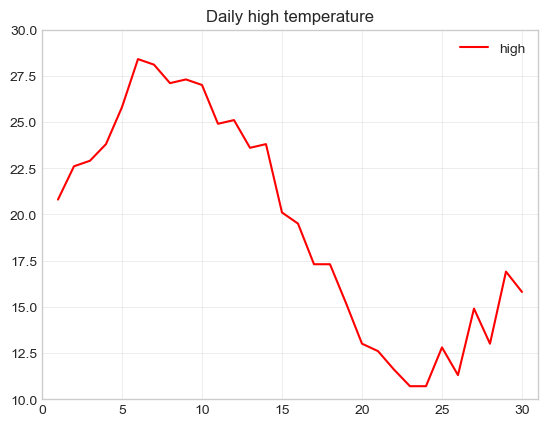

In [9]:
import matplotlib.pyplot as plt
import numpy as np

days, highs, lows = np.loadtxt('../data/temperature.csv',
                                delimiter=',', skiprows=1, unpack=True)
plt.style.use('seaborn-v0_8-whitegrid')
# ---- 开始 ----
plt.plot(days, highs, '-r', label='high')
plt.title('Daily high temperature')
plt.legend()
plt.xlim(0, 31)
plt.ylim(10, 30)
plt.show();
# ---- 结束 ----

## ✏️ 练习 1-2: 多线对比与样式

📘 04.01 Simple Line Plots

在同一张图上画出最高气温和最低气温两条线

**要求:**
- 最高温: 红色实线 ('-r')
- 最低温: 蓝色虚线 ('--b')
- 添加图例 (plt.legend)
- x轴标签 'Day', y轴标签 'Temperature (°C)'

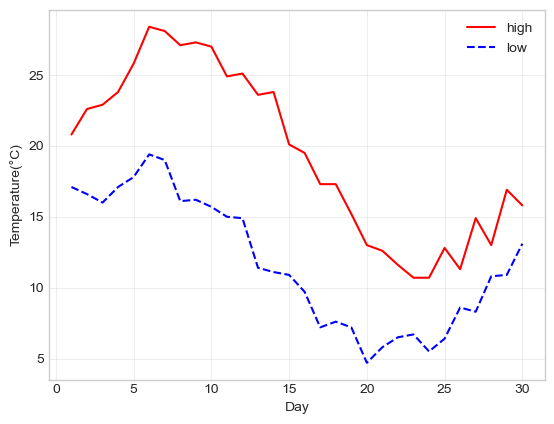

In [10]:
# ---- 开始 ----
plt.plot(days, highs, '-r', label='high')
plt.plot(days, lows, '--b', label='low')
plt.legend()
plt.xlabel('Day')
plt.ylabel('Temperature(°C)')
plt.show();
# ---- 结束 ----

## ✏️ 练习 1-3: 散点图

📘 04.02 Simple Scatter Plots

用散点图展示最高温 vs 最低温的关系

**要求:**
- 用 plt.scatter, x=最高温, y=最低温
- 点颜色为紫色 ('purple')
- 透明度 0.6 (alpha=0.6)
- 点大小随天数变化: s=days*5
- 标题 'High vs Low Temperature'

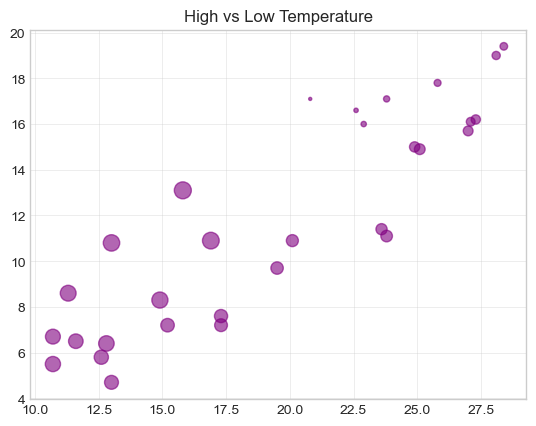

In [17]:
# ---- 开始 ----
sizes = days*5
plt.scatter(highs, lows, marker='o', color='purple', alpha=0.6, s=sizes)
plt.title('High vs Low Temperature')
plt.show();
# ---- 结束 ----

## ✏️ 🌟 练习 1-4: 误差棒图 (选做)

📘 04.03 Visualizing Errors

数据: 每周平均气温及标准差

**要求:**
- 用 plt.errorbar
- 绿色圆圈标记 ('go-')
- 误差条黑色 (ecolor='black'), 宽度 2

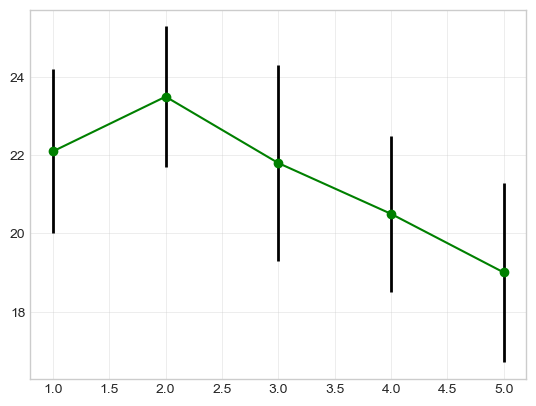

In [19]:
weekly_mean = [22.1, 23.5, 21.8, 20.5, 19.0]
weekly_std  = [2.1, 1.8, 2.5, 2.0, 2.3]
weeks = np.arange(1, 6)

# ---- 开始 ----
plt.errorbar(weeks, weekly_mean, yerr=weekly_std, fmt='-og', ecolor='black', elinewidth=2)
plt.show();
# ---- 结束 ----

---

## 📌 三个函数的参数对比总结（plot / scatter / errorbar）

| 参数类别 | `plt.plot` | `plt.scatter` | `plt.errorbar` |
|------|:---:|:---:|:---:|
| **点型** | `marker` 或 `fmt`（如 `o`） | `marker` | `fmt`（如 `o`） |
| **线型** | `linestyle` 或 `fmt`（如 `--`） | 无 | `linestyle`（`fmt` 里也可定义） |
| **点/线颜色** | `color` 或 `fmt`（如 `r`） | `c` / `color` | `color`（`fmt` 里也可定义，但会和棒同色） |
| **误差棒颜色** | 无 | 无 | `ecolor` |
| **点的填充色** | `markerfacecolor` | 同左 | 同左 |
| **点的边缘色** | `markeredgecolor` | 同左 | 同左 |

### 关键区别

- `plot`：`fmt` 作为**位置参数**直接跟在 x, y 后面，如 `plt.plot(x, y, "o--r")`
- `errorbar`：`fmt` 作为**关键字参数**显式传入，如 `plt.errorbar(x, y, yerr=dy, fmt="o")`
- `scatter`：没有 `fmt` 参数，点型用 `marker` 定义
- 只有 `errorbar` 可以显式写 `fmt=` 这个参数名；`plot` 的 `fmt` 是第三个位置参数

### 一个共同的反例

```python
# ❌ 用 fmt 给了颜色，还单独写 color，会冲突
plt.errorbar(x, y, yerr=dy, fmt='ro', color='blue', ecolor='gray')

# ✅ 正确：fmt 只给点型，颜色分开设
plt.errorbar(x, y, yerr=dy, fmt='o', color='red', ecolor='gray')
```